
# 14. Cell Type Prioritisation For The C9-SMCR8-ULK Axis

This notebook asks which **broad** and **refined** CNS cell types provide the most disease-relevant context for follow-up experiments on the **C9orf72-SMCR8-WDR41 / ULK1-RB1CC1-ATG13-ATG101 / ULK1-ULK2-TBK1** axis.

I keep the analysis publication-oriented and donor-aware throughout:

1. I reuse saved checkpoints and saved DE results where possible.
2. I treat **donors**, not cells, as the main unit for summarisation.
3. I keep biologically subjective choices explicit by exposing clearly marked placeholder variables for later review.


In [1]:

from pathlib import Path
import itertools
import warnings

import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy import sparse
from scipy.stats import zscore
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

MERGED_PB_PATH = PROJECT_ROOT / 'data' / 'processed' / 'merged' / 'adata_merged_pb.h5ad'
BROAD_PB_DIR = PROJECT_ROOT / 'results' / 'pseudobulk' / 'broad'
DE_BROAD_DIR = PROJECT_ROOT / 'results' / 'de_pseudobulk_broad'

RESULTS_14_DIR = PROJECT_ROOT / 'results' / '14_celltype_prioritisation_C9_SMCR8_ULK_axis'
FIG_DIR = RESULTS_14_DIR / 'figures'
TABLE_DIR = RESULTS_14_DIR / 'tables'
INTERMEDIATE_DIR = RESULTS_14_DIR / 'intermediate'

for path in [RESULTS_14_DIR, FIG_DIR, TABLE_DIR, INTERMEDIATE_DIR]:
    path.mkdir(parents=True, exist_ok=True)



## 1. Load Data And Define The Analysis Scope

I use the saved **full-gene pseudobulk-ready checkpoint** from notebook 10 because it already carries the broad and refined annotations from notebook 09 while preserving the full gene space needed for pathway-level expression work.


In [2]:

CORE_PANEL = [
    'C9ORF72', 'SMCR8', 'WDR41',
    'RB1CC1', 'ATG13', 'ATG101',
    'ULK1', 'ULK2', 'TBK1',
]

adata_master = ad.read_h5ad(MERGED_PB_PATH, backed='r')

required_obs_cols = ['sample', 'condition', 'cell_class_major_harmony', 'cell_subtype']
missing_obs_cols = [col for col in required_obs_cols if col not in adata_master.obs.columns]
if missing_obs_cols:
    raise KeyError(f'Missing required annotation columns in {MERGED_PB_PATH.name}: {missing_obs_cols}')

scope_summary = pd.DataFrame({
    'checkpoint': [MERGED_PB_PATH.name],
    'n_cells': [adata_master.n_obs],
    'n_genes': [adata_master.n_vars],
    'has_counts_layer': ['counts' in adata_master.layers.keys()],
    'n_samples': [adata_master.obs['sample'].nunique()],
    'conditions': [', '.join(map(str, sorted(adata_master.obs['condition'].astype(str).unique())))],
    'broad_classes': [', '.join(map(str, sorted(adata_master.obs['cell_class_major_harmony'].astype(str).dropna().unique())))],
    'n_refined_subtypes': [adata_master.obs['cell_subtype'].dropna().astype(str).nunique()],
})

display(scope_summary)
print('Top broad classes:')
display(adata_master.obs['cell_class_major_harmony'].value_counts(dropna=False).to_frame('n_cells'))
print('Top refined subtypes:')
display(adata_master.obs['cell_subtype'].value_counts(dropna=False).head(15).to_frame('n_cells'))


,checkpoint,n_cells,n_genes,has_counts_layer,n_samples,conditions,broad_classes,n_refined_subtypes
0,adata_merged_pb.h5ad,88883,61552,True,12,"Control, c9ALS, sALS","Excitatory, Glia, Inhibitory, Vascular",22


Top broad classes:


,n_cells
cell_class_major_harmony,
Glia,65529
Excitatory,16001
Inhibitory,6717
Vascular,636


Top refined subtypes:


,n_cells
cell_subtype,
Glia.Oligo,50041
Ex.L2_L3.CUX2_RASGRF2,6768
Glia.Astro.GFAP.neg,5246
Glia.OPC,5143
Glia.Micro,3327
In.5HT3aR.DISC1_RELN,2464
Ex.L4_L6.RORB_LRRK1,1908
In.PV.PVALB_MYBPC1,1884
Ex.L5_L6.THEMIS_TMEM233,1818



## 2. Sanity Checks On Gene Availability

I keep the requested panel fixed, but I allow **case-insensitive matching** so that project-internal gene naming differences such as `C9orf72` versus `C9ORF72` are handled transparently. I still report those matches explicitly rather than hiding them.


In [3]:

def build_gene_availability_table(var_names, requested_genes):
    var_names = pd.Index(var_names.astype(str))
    upper_lookup = {gene.upper(): gene for gene in var_names}
    rows = []
    requested_to_var = {}

    for gene in requested_genes:
        if gene in var_names:
            matched_gene = gene
            match_type = 'exact'
            present = True
        elif gene.upper() in upper_lookup:
            matched_gene = upper_lookup[gene.upper()]
            match_type = 'case_insensitive'
            present = True
        else:
            matched_gene = pd.NA
            match_type = 'missing'
            present = False

        if present:
            requested_to_var[gene] = matched_gene

        rows.append({
            'requested_gene': gene,
            'matched_var_name': matched_gene,
            'match_type': match_type,
            'present': present,
        })

    availability_df = pd.DataFrame(rows)
    return availability_df, requested_to_var


gene_availability_df, requested_to_var = build_gene_availability_table(adata_master.var_names, CORE_PANEL)
present_requested_genes = gene_availability_df.loc[gene_availability_df['present'], 'requested_gene'].tolist()
missing_requested_genes = gene_availability_df.loc[~gene_availability_df['present'], 'requested_gene'].tolist()
var_to_requested = {v: k for k, v in requested_to_var.items()}

gene_availability_df.to_csv(TABLE_DIR / '14_gene_availability_core_axis.csv', index=False)
display(gene_availability_df)

if missing_requested_genes:
    print('Missing genes will be excluded from downstream summaries:')
    print(missing_requested_genes)
else:
    print('All requested genes are available after exact/case-insensitive matching.')

adata_core = adata_master[:, [requested_to_var[g] for g in present_requested_genes]].to_memory()
adata_core.var['requested_gene'] = [var_to_requested[g] for g in adata_core.var_names]


,requested_gene,matched_var_name,match_type,present
0,C9ORF72,C9orf72,case_insensitive,True
1,SMCR8,SMCR8,exact,True
2,WDR41,WDR41,exact,True
3,RB1CC1,RB1CC1,exact,True
4,ATG13,ATG13,exact,True
5,ATG101,ATG101,exact,True
6,ULK1,ULK1,exact,True
7,ULK2,ULK2,exact,True
8,TBK1,TBK1,exact,True


All requested genes are available after exact/case-insensitive matching.



## 3. Analysis Placeholders For Manual Review

The defaults below are deliberately simple and interpretable, but they are still analysis choices rather than biological truths. I keep them in one place so they are easy to inspect and edit before final interpretation.


In [18]:

# ------------------------------------------------------------------
# Placeholder settings to review before final interpretation.
# ------------------------------------------------------------------

MIN_CELLS_PER_SUBTYPE_SAMPLE = 20
MIN_DONORS_PER_CONDITION_FOR_SUBTYPE_DE = 3
MIN_DONORS_FOR_CORRELATION = 4

PERTURBED_PADJ_THRESHOLD = 0.10
PERTURBED_LFC_THRESHOLD = 0.25

TOP_N_SUBTYPES_TO_PLOT = 20
TOP_N_SUBTYPES_TO_PLOT_FOR_PERTURBATION = 15

# I default to a simple equal-weight pathway score based on mean z-scored
# expression across the present core genes. I keep the weights editable.
PATHWAY_SCORE_GENE_WEIGHTS = {gene: 1.0 for gene in present_requested_genes}

# I leave these empty by default. If they stay empty, I will auto-select
# top groups from the baseline ranking for correlation heatmaps.
SELECTED_BROAD_CORRELATION_PANELS = ["Excitatory"]
SELECTED_SUBTYPE_CORRELATION_PANELS = ["Glia.Micro"]

# I keep the prioritisation score intentionally simple and transparent.
PRIORITISATION_WEIGHTS = {
    'baseline': 1.0,
    'coordination': 1.0,
    'perturbation': 1.0,
    'robustness': 0.5,
}

DE_COMPARISON_CONFIG = {
    'c9ALS_vs_Control': {'file_stem': 'Control_vs_c9ALS', 'test': 'c9ALS', 'ref': 'Control'},
    'c9ALS_vs_sALS': {'file_stem': 'sALS_vs_c9ALS', 'test': 'c9ALS', 'ref': 'sALS'},
    'sALS_vs_Control': {'file_stem': 'Control_vs_sALS', 'test': 'sALS', 'ref': 'Control'},
}



## Helper Functions

I keep the reusable logic here so the downstream sections stay readable and so the saved outputs are generated consistently.


In [19]:

def matrix_to_dataframe(matrix, obs_names, var_names):
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return pd.DataFrame(matrix, index=pd.Index(obs_names, name='obs_name'), columns=list(var_names))


core_counts_df = matrix_to_dataframe(
    adata_core.layers['counts'] if 'counts' in adata_core.layers else adata_core.X,
    adata_core.obs_names,
    adata_core.var['requested_gene'].tolist(),
)
core_obs_df = adata_core.obs[['sample', 'condition', 'cell_class_major_harmony', 'cell_subtype']].copy()
core_obs_df.index = core_counts_df.index


def counts_to_cpm_and_logcpm(counts_df):
    lib_sizes = counts_df.sum(axis=1)
    lib_sizes = lib_sizes.replace(0, np.nan)
    cpm = counts_df.div(lib_sizes, axis=0) * 1e6
    cpm = cpm.fillna(0.0)
    logcpm = np.log1p(cpm)
    return cpm, logcpm


def compute_weighted_pathway_score(mean_expr_df, weights):
    if mean_expr_df.empty:
        return pd.Series(dtype=float)

    present_weights = pd.Series(weights, dtype=float)
    present_weights = present_weights.loc[present_weights.index.intersection(mean_expr_df.columns)]
    if present_weights.empty:
        raise ValueError('No overlap between pathway score weights and mean expression columns.')

    expr_use = mean_expr_df.loc[:, present_weights.index]
    z_expr = expr_use.apply(lambda col: pd.Series(zscore(col, nan_policy='omit'), index=col.index), axis=0)
    z_expr = z_expr.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    score = z_expr.mul(present_weights, axis=1).sum(axis=1) / present_weights.sum()
    return score


def save_heatmap(df, title, out_path, cmap='mako', center=None, figsize_scale=(0.75, 0.55)):
    if df.empty:
        return
    fig_w = max(8, df.shape[1] * figsize_scale[0] + 4)
    fig_h = max(4, df.shape[0] * figsize_scale[1] + 2)
    plt.figure(figsize=(fig_w, fig_h))
    sns.heatmap(df, cmap=cmap, center=center, linewidths=0.5, linecolor='white')
    plt.title(title)
    plt.xlabel(df.columns.name if df.columns.name else '')
    plt.ylabel(df.index.name if df.index.name else '')
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def save_dotplot_summary(mean_expr_df, fraction_df, title, out_path):
    if mean_expr_df.empty:
        return

    long_df = (
        mean_expr_df.rename_axis(index='group_name', columns='gene')
        .stack()
        .rename('mean_logCPM')
        .reset_index()
    )
    long_df = long_df.merge(
        fraction_df.rename_axis(index='group_name', columns='gene').stack().rename('fraction_detected').reset_index(),
        on=['group_name', 'gene'],
        how='left',
    )

    x_order = list(mean_expr_df.columns)
    y_order = list(mean_expr_df.index)
    x_pos = {gene: i for i, gene in enumerate(x_order)}
    y_pos = {group: i for i, group in enumerate(y_order)}

    plt.figure(figsize=(max(8, len(x_order) * 1.0 + 2), max(4, len(y_order) * 0.5 + 2)))
    scatter = plt.scatter(
        long_df['gene'].map(x_pos),
        long_df['group_name'].map(y_pos),
        s=80 + 420 * long_df['fraction_detected'].fillna(0.0),
        c=long_df['mean_logCPM'],
        cmap='mako',
        edgecolor='black',
        linewidth=0.4,
    )
    plt.colorbar(scatter, label='Mean logCPM')
    plt.xticks(range(len(x_order)), x_order, rotation=45, ha='right')
    plt.yticks(range(len(y_order)), y_order)
    plt.title(title)
    plt.xlabel('Core gene')
    plt.ylabel('Cell type')
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()


def build_ranking_table(mean_expr_df, score_series, n_donors_series, level_name):
    ranking_rows = []
    for gene in mean_expr_df.columns:
        ranked = mean_expr_df[gene].sort_values(ascending=False)
        for rank, (group_name, value) in enumerate(ranked.items(), start=1):
            ranking_rows.append({
                'level': level_name,
                'ranking_type': 'gene_expression',
                'feature': gene,
                'rank': rank,
                'group_name': group_name,
                'value': value,
                'n_control_donors': n_donors_series.get(group_name, np.nan),
            })

    ranked_score = score_series.sort_values(ascending=False)
    for rank, (group_name, value) in enumerate(ranked_score.items(), start=1):
        ranking_rows.append({
            'level': level_name,
            'ranking_type': 'composite_pathway_score',
            'feature': 'core_axis_score',
            'rank': rank,
            'group_name': group_name,
            'value': value,
            'n_control_donors': n_donors_series.get(group_name, np.nan),
        })

    return pd.DataFrame(ranking_rows)


def load_saved_broad_pseudobulk(requested_to_var):
    counts_by_group = {}
    meta_by_group = {}

    for group_name in ['Excitatory', 'Inhibitory', 'Glia', 'Vascular']:
        counts_path = BROAD_PB_DIR / f'{group_name}_counts.csv'
        meta_path = BROAD_PB_DIR / f'{group_name}_meta.csv'
        if not counts_path.exists() or not meta_path.exists():
            warnings.warn(f'Missing saved broad pseudobulk input for {group_name}; skipping.')
            continue

        counts_df = pd.read_csv(counts_path, index_col=0)

        # I read the metadata without index_col here because the first column
        # in the saved broad metadata files is 'sample', and I want to keep
        # that as an explicit column for donor-retention summaries.
        meta_df = pd.read_csv(meta_path)

        counts_df.index = counts_df.index.astype(str)
        meta_df['sample'] = meta_df['sample'].astype(str)

        # I create a unique pseudobulk ID so the counts and metadata tables
        # can be combined across broad classes without index collisions.
        unique_ids = pd.Index(
            [f'{group_name}__{sample_id}' for sample_id in counts_df.index],
            name='pseudobulk_id',
        )
        counts_df.index = unique_ids
        meta_df.index = unique_ids

        selected_cols = {}
        for requested_gene, var_name in requested_to_var.items():
            if var_name in counts_df.columns:
                selected_cols[var_name] = requested_gene

        counts_core = counts_df.loc[:, list(selected_cols.keys())].rename(columns=selected_cols)
        meta_df['group_name'] = group_name

        counts_by_group[group_name] = counts_core
        meta_by_group[group_name] = meta_df

    return counts_by_group, meta_by_group


def build_grouped_pseudobulk_from_cells(counts_df, obs_df, groupby_col, min_cells_per_sample):
    work_obs = obs_df[['sample', 'condition', groupby_col]].copy()
    work_obs = work_obs.dropna(subset=[groupby_col]).copy()
    work_obs[groupby_col] = work_obs[groupby_col].astype(str)

    counts_use = counts_df.loc[work_obs.index].copy()
    counts_use['sample'] = work_obs['sample'].astype(str).values
    counts_use['condition'] = work_obs['condition'].astype(str).values
    counts_use[groupby_col] = work_obs[groupby_col].values

    grouped = counts_use.groupby([groupby_col, 'sample', 'condition'], sort=True)
    pb_counts = grouped[present_requested_genes].sum()
    n_cells = grouped.size().rename('n_cells')

    pb_meta = n_cells.reset_index()
    pb_meta['pseudobulk_id'] = pb_meta.apply(lambda row: f"{row[groupby_col]}__{row['sample']}__{row['condition']}", axis=1)
    pb_meta = pb_meta.set_index('pseudobulk_id')

    pb_counts = pb_counts.reset_index()
    pb_counts['pseudobulk_id'] = pb_counts.apply(lambda row: f"{row[groupby_col]}__{row['sample']}__{row['condition']}", axis=1)
    pb_counts = pb_counts.set_index('pseudobulk_id')
    pb_counts = pb_counts.loc[:, present_requested_genes]

    keep_ids = pb_meta.index[pb_meta['n_cells'] >= min_cells_per_sample]
    pb_meta = pb_meta.loc[keep_ids].copy()
    pb_counts = pb_counts.loc[keep_ids].copy()

    return pb_counts.astype(int), pb_meta


def build_retention_summary(meta_df, group_col, level_name):
    summary = (
        meta_df.groupby([group_col, 'condition'])
        .agg(
            n_retained_donors=('sample', 'nunique'),
            min_cells=('n_cells', 'min'),
            median_cells=('n_cells', 'median'),
            max_cells=('n_cells', 'max'),
        )
        .reset_index()
        .rename(columns={group_col: 'group_name'})
    )
    summary['level'] = level_name
    return summary


def summarise_baseline_from_pseudobulk(counts_df, meta_df, group_col, level_name, top_n_plot=None):
    cpm_df, logcpm_df = counts_to_cpm_and_logcpm(counts_df)
    control_mask = meta_df['condition'].astype(str).eq('Control')
    control_meta = meta_df.loc[control_mask].copy()
    control_cpm = cpm_df.loc[control_mask].copy()
    control_logcpm = logcpm_df.loc[control_mask].copy()

    tmp_log = control_logcpm.copy()
    tmp_log[group_col] = control_meta[group_col].astype(str).values
    mean_expr = tmp_log.groupby(group_col).mean()

    tmp_fraction = (control_cpm > 1.0).astype(float)
    tmp_fraction[group_col] = control_meta[group_col].astype(str).values
    fraction_df = tmp_fraction.groupby(group_col).mean()

    control_donor_counts = control_meta.groupby(group_col)['sample'].nunique()
    pathway_score = compute_weighted_pathway_score(mean_expr, PATHWAY_SCORE_GENE_WEIGHTS)

    baseline_summary = pd.DataFrame({
        'group_name': mean_expr.index,
        'n_control_donors': control_donor_counts.reindex(mean_expr.index).values,
        'baseline_pathway_score': pathway_score.reindex(mean_expr.index).values,
        'baseline_mean_logCPM': mean_expr.mean(axis=1).reindex(mean_expr.index).values,
    }).sort_values('baseline_pathway_score', ascending=False)

    ranking_table = build_ranking_table(mean_expr, pathway_score, control_donor_counts, level_name)

    plot_order = baseline_summary['group_name'].tolist()
    if top_n_plot is not None:
        plot_order = plot_order[:top_n_plot]

    mean_expr_plot = mean_expr.loc[plot_order]
    fraction_plot = fraction_df.loc[plot_order]

    mean_expr.to_csv(TABLE_DIR / f'14_{level_name}_baseline_control_mean_logcpm.csv')
    fraction_df.to_csv(TABLE_DIR / f'14_{level_name}_baseline_control_fraction_detected.csv')
    baseline_summary.to_csv(TABLE_DIR / f'14_{level_name}_baseline_control_summary.csv', index=False)
    ranking_table.to_csv(TABLE_DIR / f'14_{level_name}_baseline_control_rankings.csv', index=False)

    save_heatmap(
        mean_expr_plot,
        title=f'{level_name.replace("_", " ").title()} | Control baseline expression of the core axis',
        out_path=FIG_DIR / f'14_{level_name}_baseline_control_heatmap_core_axis.png',
        cmap='mako',
        center=None,
    )
    save_dotplot_summary(
        mean_expr_plot,
        fraction_plot,
        title=f'{level_name.replace("_", " ").title()} | Control donor-level dotplot summary',
        out_path=FIG_DIR / f'14_{level_name}_baseline_control_dotplot_core_axis.png',
    )

    return {
        'counts': counts_df,
        'meta': meta_df,
        'cpm': cpm_df,
        'logcpm': logcpm_df,
        'mean_expr': mean_expr,
        'fraction': fraction_df,
        'summary': baseline_summary,
        'rankings': ranking_table,
    }


def mean_pairwise_correlation(corr_df):
    if corr_df.shape[0] < 2:
        return np.nan
    upper_idx = np.triu_indices_from(corr_df, k=1)
    values = corr_df.to_numpy()[upper_idx]
    if values.size == 0:
        return np.nan
    return float(np.nanmean(values))


def summarise_coordination_from_pseudobulk(logcpm_df, meta_df, group_col, level_name, min_donors, candidate_groups=None):
    control_mask = meta_df['condition'].astype(str).eq('Control')
    control_meta = meta_df.loc[control_mask].copy()
    control_logcpm = logcpm_df.loc[control_mask].copy()

    rows = []
    corr_mats = {}

    for group_name in sorted(control_meta[group_col].astype(str).unique()):
        idx = control_meta.index[control_meta[group_col].astype(str).eq(group_name)]
        donor_mat = control_logcpm.loc[idx, present_requested_genes]
        n_donors = donor_mat.shape[0]

        if n_donors < min_donors:
            rows.append({
                'level': level_name,
                'group_name': group_name,
                'n_control_donors': n_donors,
                'coordination_mean_pairwise_r': np.nan,
                'coordination_flag': 'insufficient_donors',
            })
            continue

        corr_df = donor_mat.corr(method='pearson')
        corr_mats[group_name] = corr_df
        rows.append({
            'level': level_name,
            'group_name': group_name,
            'n_control_donors': n_donors,
            'coordination_mean_pairwise_r': mean_pairwise_correlation(corr_df),
            'coordination_flag': 'tentative_low_n' if n_donors < 5 else 'ok',
        })

    summary_df = pd.DataFrame(rows).sort_values('coordination_mean_pairwise_r', ascending=False, na_position='last')
    summary_df.to_csv(TABLE_DIR / f'14_{level_name}_coordination_summary.csv', index=False)

    candidate_groups = candidate_groups or []
    for group_name in candidate_groups:
        if group_name not in corr_mats:
            continue
        save_heatmap(
            corr_mats[group_name].loc[present_requested_genes, present_requested_genes],
            title=f'{group_name} | Control donor-level core-axis coordination',
            out_path=FIG_DIR / f'14_{level_name}_coordination_heatmap_{group_name.replace("/", "_").replace(" ", "_")}.png',
            cmap='vlag',
            center=0,
            figsize_scale=(0.9, 0.8),
        )

    return summary_df, corr_mats


def load_broad_de_core(level_name='broad'):
    rows = []
    for group_name in ['Excitatory', 'Inhibitory', 'Glia', 'Vascular']:
        for comparison_name, cfg in DE_COMPARISON_CONFIG.items():
            fn = DE_BROAD_DIR / f"{group_name}_{cfg['file_stem']}.csv"
            if not fn.exists():
                continue
            df = pd.read_csv(fn)
            if 'gene' not in df.columns:
                continue
            gene_lookup = {gene.upper(): gene for gene in df['gene'].astype(str)}
            for requested_gene in CORE_PANEL:
                matched_gene = gene_lookup.get(requested_gene.upper())
                if matched_gene is None:
                    continue
                hit = df.loc[df['gene'].astype(str).eq(matched_gene)].copy()
                if hit.empty:
                    continue
                hit = hit.iloc[[0]].copy()
                hit['requested_gene'] = requested_gene
                hit['group_name'] = group_name
                hit['comparison'] = comparison_name
                hit['level'] = level_name
                rows.append(hit)

    if not rows:
        return pd.DataFrame(columns=['level', 'group_name', 'comparison', 'requested_gene', 'gene', 'log2FoldChange', 'pvalue', 'padj'])

    out_df = pd.concat(rows, ignore_index=True)
    out_df.to_csv(TABLE_DIR / f'14_{level_name}_core_axis_de_long.csv', index=False)
    return out_df


def get_deseq_results_dataframe(stats_obj):
    summary_res = stats_obj.summary()
    if isinstance(summary_res, pd.DataFrame):
        res = summary_res.copy()
    elif hasattr(stats_obj, 'results_df'):
        res = stats_obj.results_df.copy()
    else:
        raise AttributeError('Could not extract DESeq2 results from DeseqStats object.')

    if 'gene' not in res.columns:
        res = res.reset_index().rename(columns={'index': 'gene'})
    return res


def run_core_deseq_for_one_group(counts_df, meta_df, test_condition, ref_condition):
    keep_mask = meta_df['condition'].astype(str).isin([test_condition, ref_condition])
    counts_use = counts_df.loc[keep_mask].copy()
    meta_use = meta_df.loc[keep_mask, ['condition']].copy()

    if counts_use.empty:
        return pd.DataFrame()

    meta_use['condition'] = pd.Categorical(meta_use['condition'].astype(str), categories=[ref_condition, test_condition])
    counts_use = counts_use.astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design='~condition',
        refit_cooks=True,
    )
    dds.deseq2()
    stats = DeseqStats(dds, contrast=['condition', test_condition, ref_condition])
    stats.summary()
    return get_deseq_results_dataframe(stats)


def run_subtype_core_de(counts_df, meta_df, group_col, min_donors_per_condition):
    rows = []
    failures = []

    retention = (
        meta_df.groupby([group_col, 'condition'])['sample']
        .nunique()
        .reset_index(name='n_retained_donors')
    )
    retention.to_csv(TABLE_DIR / '14_subtype_de_retention_by_condition.csv', index=False)

    for subtype_name in sorted(meta_df[group_col].astype(str).unique()):
        meta_sub = meta_df.loc[meta_df[group_col].astype(str).eq(subtype_name)].copy()
        counts_sub = counts_df.loc[meta_sub.index].copy()

        for comparison_name, cfg in DE_COMPARISON_CONFIG.items():
            donor_counts = meta_sub.groupby('condition')['sample'].nunique().to_dict()
            if donor_counts.get(cfg['test'], 0) < min_donors_per_condition or donor_counts.get(cfg['ref'], 0) < min_donors_per_condition:
                failures.append({
                    'group_name': subtype_name,
                    'comparison': comparison_name,
                    'status': 'insufficient_donors',
                    'n_test_donors': donor_counts.get(cfg['test'], 0),
                    'n_ref_donors': donor_counts.get(cfg['ref'], 0),
                })
                continue

            try:
                res = run_core_deseq_for_one_group(counts_sub, meta_sub, cfg['test'], cfg['ref'])
                if res.empty:
                    failures.append({
                        'group_name': subtype_name,
                        'comparison': comparison_name,
                        'status': 'empty_result',
                        'n_test_donors': donor_counts.get(cfg['test'], 0),
                        'n_ref_donors': donor_counts.get(cfg['ref'], 0),
                    })
                    continue
                res['requested_gene'] = res['gene'].astype(str).map(lambda g: g if g in present_requested_genes else var_to_requested.get(g, g))
                res['group_name'] = subtype_name
                res['comparison'] = comparison_name
                res['level'] = 'subtype'
                rows.append(res)
            except Exception as exc:
                failures.append({
                    'group_name': subtype_name,
                    'comparison': comparison_name,
                    'status': f'failed: {exc}',
                    'n_test_donors': donor_counts.get(cfg['test'], 0),
                    'n_ref_donors': donor_counts.get(cfg['ref'], 0),
                })

    de_long_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    failure_df = pd.DataFrame(failures)
    de_long_df.to_csv(TABLE_DIR / '14_subtype_core_axis_de_long.csv', index=False)
    failure_df.to_csv(TABLE_DIR / '14_subtype_core_axis_de_failures.csv', index=False)
    return de_long_df, failure_df


def build_perturbation_summary(de_long_df, level_name, top_n_plot=None):
    if de_long_df.empty:
        return pd.DataFrame(), {}

    work = de_long_df.copy()
    work['perturbed'] = (
        work['padj'].notna()
        & work['log2FoldChange'].notna()
        & (work['padj'] <= PERTURBED_PADJ_THRESHOLD)
        & (work['log2FoldChange'].abs() >= PERTURBED_LFC_THRESHOLD)
    )

    summary = (
        work.groupby(['group_name', 'comparison'])
        .agg(
            n_core_genes_tested=('requested_gene', 'nunique'),
            n_perturbed_genes=('perturbed', 'sum'),
            mean_abs_log2fc=('log2FoldChange', lambda s: np.nanmean(np.abs(s))),
        )
        .reset_index()
    )

    mean_abs_log2fc_perturbed = (
        work.loc[work['perturbed']]
        .groupby(['group_name', 'comparison'])['log2FoldChange']
        .apply(lambda s: np.nanmean(np.abs(s)))
        .rename('mean_abs_log2fc_perturbed')
        .reset_index()
    )
    summary = summary.merge(mean_abs_log2fc_perturbed, on=['group_name', 'comparison'], how='left')
    summary['level'] = level_name
    summary.to_csv(TABLE_DIR / f'14_{level_name}_perturbation_summary.csv', index=False)

    heatmaps = {}
    for comparison_name in work['comparison'].dropna().unique():
        heatmap_df = (
            work.loc[work['comparison'].eq(comparison_name), ['group_name', 'requested_gene', 'log2FoldChange']]
            .pivot(index='group_name', columns='requested_gene', values='log2FoldChange')
        )
        group_order = (
            summary.loc[summary['comparison'].eq(comparison_name)]
            .sort_values(['n_perturbed_genes', 'mean_abs_log2fc'], ascending=[False, False])['group_name']
            .tolist()
        )
        if top_n_plot is not None:
            group_order = group_order[:top_n_plot]
        heatmap_plot = heatmap_df.reindex(group_order)
        heatmaps[comparison_name] = heatmap_df
        save_heatmap(
            heatmap_plot,
            title=f'{level_name.title()} | {comparison_name} effect sizes across the core axis',
            out_path=FIG_DIR / f'14_{level_name}_perturbation_heatmap_{comparison_name}.png',
            cmap='vlag',
            center=0,
        )

    work.to_csv(TABLE_DIR / f'14_{level_name}_perturbation_long_table.csv', index=False)
    return summary, heatmaps


def minmax_scale(series):
    s = series.astype(float).copy()
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=s.index)
    min_val = s.min(skipna=True)
    max_val = s.max(skipna=True)
    if pd.isna(min_val) or pd.isna(max_val) or np.isclose(max_val, min_val):
        return pd.Series(0.5, index=s.index)
    return (s - min_val) / (max_val - min_val)


def build_prioritisation_table(level_name, baseline_summary, coordination_summary, perturbation_summary, retention_summary):
    out = baseline_summary[['group_name', 'baseline_pathway_score', 'n_control_donors']].copy()
    out = out.merge(
        coordination_summary[['group_name', 'coordination_mean_pairwise_r', 'coordination_flag']],
        on='group_name',
        how='left',
    )

    perturbation_focus = (
        perturbation_summary.loc[perturbation_summary['comparison'].isin(['c9ALS_vs_Control', 'c9ALS_vs_sALS'])]
        .groupby('group_name')
        .agg(
            perturbation_metric=('mean_abs_log2fc', 'mean'),
            n_perturbed_core_genes=('n_perturbed_genes', 'sum'),
        )
        .reset_index()
    )
    out = out.merge(perturbation_focus, on='group_name', how='left')

    robustness = retention_summary.groupby('group_name')['n_retained_donors'].min().rename('min_retained_donors').reset_index()
    out = out.merge(robustness, on='group_name', how='left')
    out['level'] = level_name

    out['baseline_scaled'] = minmax_scale(out['baseline_pathway_score'])
    out['coordination_scaled'] = minmax_scale(out['coordination_mean_pairwise_r'].fillna(out['coordination_mean_pairwise_r'].min(skipna=True)))
    out['perturbation_scaled'] = minmax_scale(out['perturbation_metric'].fillna(0.0))
    out['robustness_scaled'] = minmax_scale(out['min_retained_donors'].fillna(0.0))

    out['prioritisation_score'] = (
        PRIORITISATION_WEIGHTS['baseline'] * out['baseline_scaled']
        + PRIORITISATION_WEIGHTS['coordination'] * out['coordination_scaled']
        + PRIORITISATION_WEIGHTS['perturbation'] * out['perturbation_scaled']
        + PRIORITISATION_WEIGHTS['robustness'] * out['robustness_scaled']
    )
    out = out.sort_values('prioritisation_score', ascending=False).reset_index(drop=True)
    out['prioritisation_rank'] = np.arange(1, len(out) + 1)
    out.to_csv(TABLE_DIR / f'14_{level_name}_integrated_prioritisation.csv', index=False)
    return out



## 3. Baseline Expression Analysis In Controls Only

I summarise baseline pathway representation at the **broad class** and **refined subtype** level using donor-level pseudobulk quantities. Broad classes are loaded from the saved broad pseudobulk outputs; refined subtypes are generated on the fly from the annotated full-gene object using only the core panel.


In [9]:

broad_counts_by_group, broad_meta_by_group = load_saved_broad_pseudobulk(requested_to_var)

broad_counts_combined = pd.concat(broad_counts_by_group.values(), axis=0)
broad_meta_combined = pd.concat(broad_meta_by_group.values(), axis=0)
broad_meta_combined.index = broad_counts_combined.index
broad_meta_combined['group_name'] = broad_meta_combined['group_name'].astype(str)

subtype_pb_counts, subtype_pb_meta = build_grouped_pseudobulk_from_cells(
    core_counts_df,
    core_obs_df,
    groupby_col='cell_subtype',
    min_cells_per_sample=MIN_CELLS_PER_SUBTYPE_SAMPLE,
)

broad_retention_summary = build_retention_summary(broad_meta_combined, 'group_name', 'broad')
subtype_retention_summary = build_retention_summary(subtype_pb_meta, 'cell_subtype', 'subtype')

broad_retention_summary.to_csv(TABLE_DIR / '14_broad_donor_retention_summary.csv', index=False)
subtype_retention_summary.to_csv(TABLE_DIR / '14_subtype_donor_retention_summary.csv', index=False)

print('Broad donor retention:')
display(broad_retention_summary)
print('Subtype donor retention (top 20 by retained donors):')
display(subtype_retention_summary.sort_values(['n_retained_donors', 'median_cells'], ascending=[False, False]).head(20))


Broad donor retention:


,group_name,condition,n_retained_donors,min_cells,median_cells,max_cells,level
0,Excitatory,Control,4,530,752.5,847,broad
1,Excitatory,c9ALS,4,1346,2333.5,2844,broad
2,Excitatory,sALS,4,152,1009.0,2092,broad
3,Glia,Control,4,2303,4792.5,5228,broad
4,Glia,c9ALS,4,4309,4901.5,5918,broad
5,Glia,sALS,4,4883,6662.5,10175,broad
6,Inhibitory,Control,4,125,253.0,409,broad
7,Inhibitory,c9ALS,4,375,854.0,1410,broad
8,Inhibitory,sALS,4,70,523.5,1067,broad
9,Vascular,Control,3,21,30.0,64,broad


Subtype donor retention (top 20 by retained donors):


,group_name,condition,n_retained_donors,min_cells,median_cells,max_cells,level
46,Glia.Oligo,sALS,4,3508,5494.5,8706,subtype
45,Glia.Oligo,c9ALS,4,3112,3507.5,4585,subtype
44,Glia.Oligo,Control,4,1473,3444.5,3764,subtype
1,Ex.L2_L3.CUX2_RASGRF2,c9ALS,4,540,958.5,1307,subtype
2,Ex.L2_L3.CUX2_RASGRF2,sALS,4,22,507.5,1260,subtype
43,Glia.OPC,sALS,4,252,503.5,569,subtype
31,Glia.Astro.GFAP.neg,c9ALS,4,342,453.0,514,subtype
30,Glia.Astro.GFAP.neg,Control,4,141,432.0,626,subtype
32,Glia.Astro.GFAP.neg,sALS,4,93,426.0,908,subtype
42,Glia.OPC,c9ALS,4,324,382.5,496,subtype


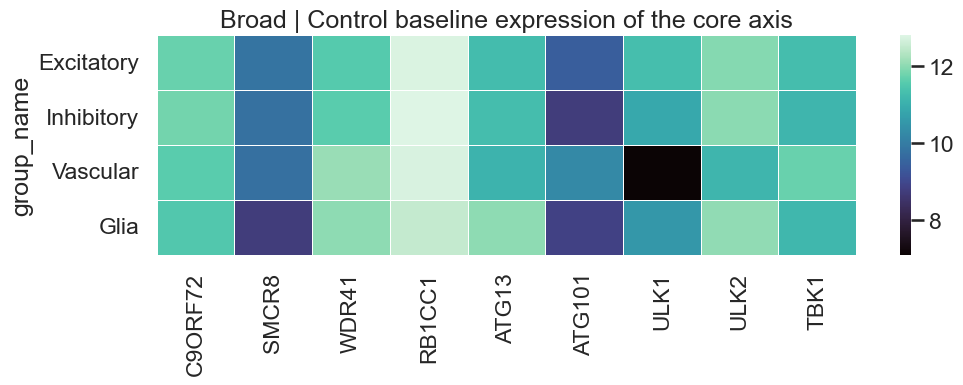

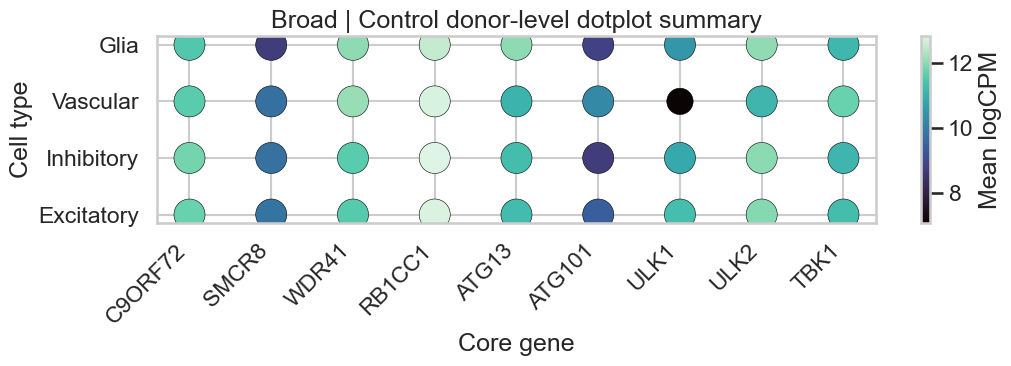

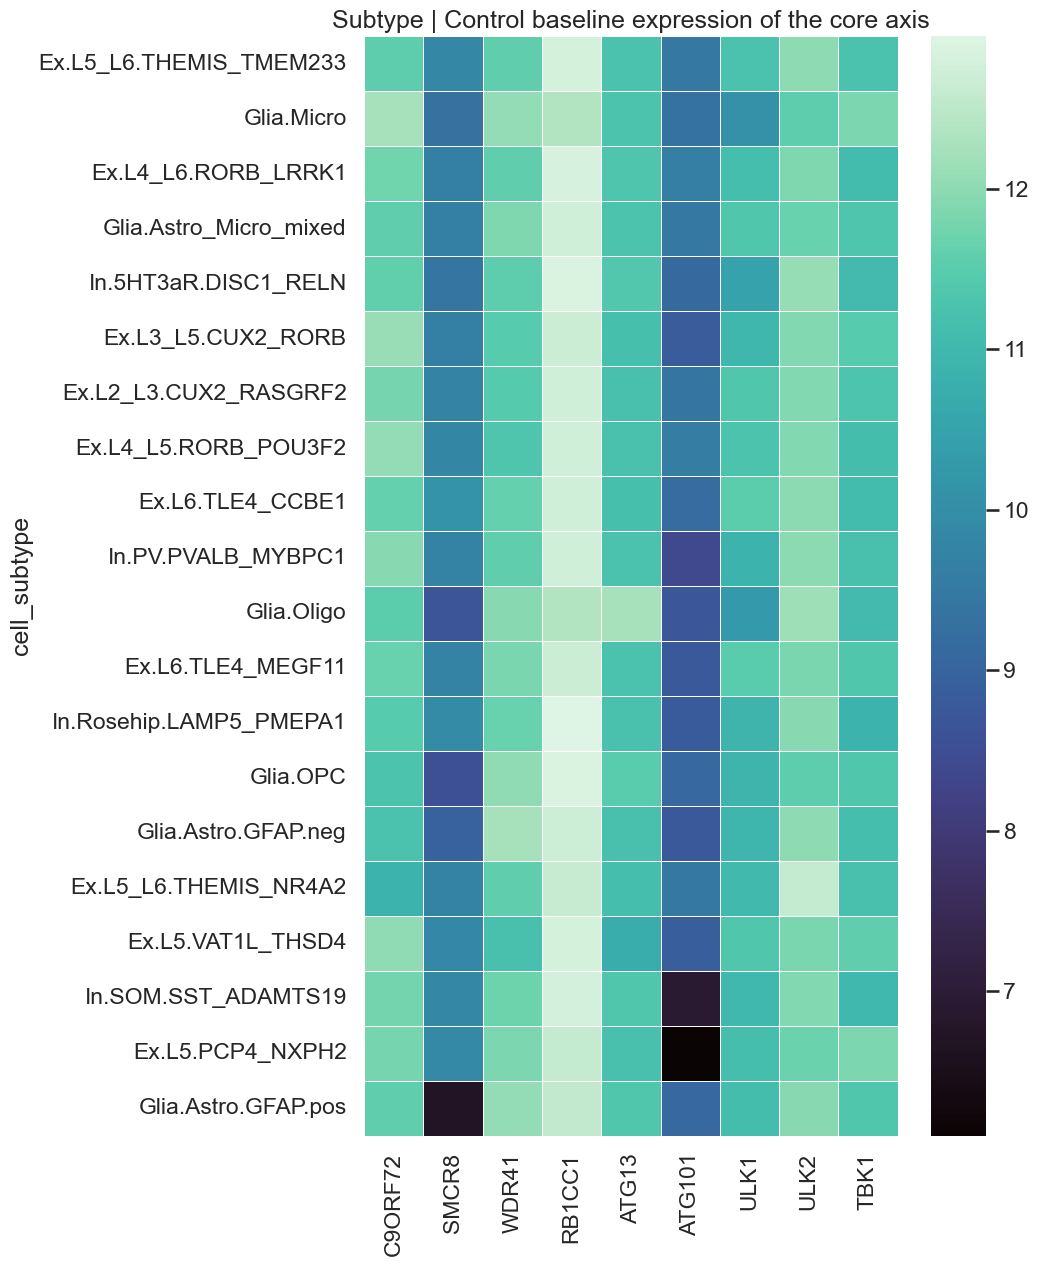

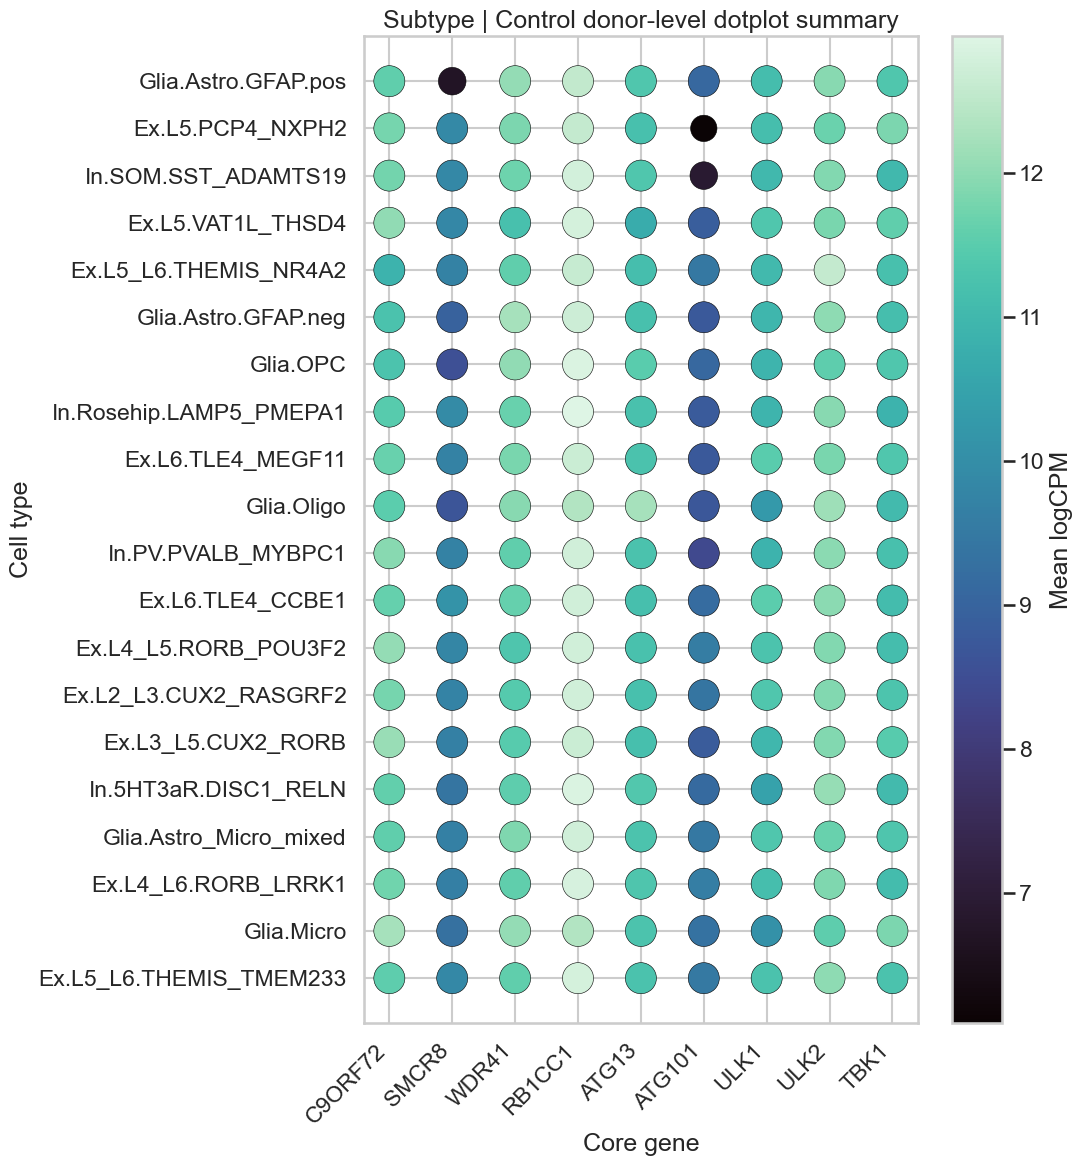

Broad baseline summary:


,group_name,n_control_donors,baseline_pathway_score,baseline_mean_logCPM
0,Excitatory,4,0.158687,11.225916
2,Inhibitory,4,0.093561,11.104698
3,Vascular,3,0.032124,10.826581
1,Glia,4,-0.284372,11.042878


Top refined subtypes by baseline pathway score:


,group_name,n_control_donors,baseline_pathway_score,baseline_mean_logCPM
7,Ex.L5_L6.THEMIS_TMEM233,4,0.140926,11.220234
13,Glia.Micro,4,0.139800,11.111945
3,Ex.L4_L6.RORB_LRRK1,4,0.128428,11.199982
12,Glia.Astro_Micro_mixed,2,0.116446,11.213418
16,In.5HT3aR.DISC1_RELN,4,0.104933,11.065635
1,Ex.L3_L5.CUX2_RORB,4,0.095627,11.139799
0,Ex.L2_L3.CUX2_RASGRF2,4,0.081984,11.207479
2,Ex.L4_L5.RORB_POU3F2,4,0.080027,11.224891
8,Ex.L6.TLE4_CCBE1,4,0.072887,11.227291
17,In.PV.PVALB_MYBPC1,4,0.061888,11.072661


In [10]:

broad_baseline = summarise_baseline_from_pseudobulk(
    broad_counts_combined,
    broad_meta_combined,
    group_col='group_name',
    level_name='broad',
    top_n_plot=None,
)

subtype_baseline = summarise_baseline_from_pseudobulk(
    subtype_pb_counts,
    subtype_pb_meta,
    group_col='cell_subtype',
    level_name='subtype',
    top_n_plot=TOP_N_SUBTYPES_TO_PLOT,
)

print('Broad baseline summary:')
display(broad_baseline['summary'])
print('Top refined subtypes by baseline pathway score:')
display(subtype_baseline['summary'].head(20))



## 4. Coordinated Expression Analysis In Controls

I treat donor-to-donor coordination of the core axis as a separate signal from baseline abundance. Where donor numbers are too low, I flag the cell type instead of forcing an interpretation.


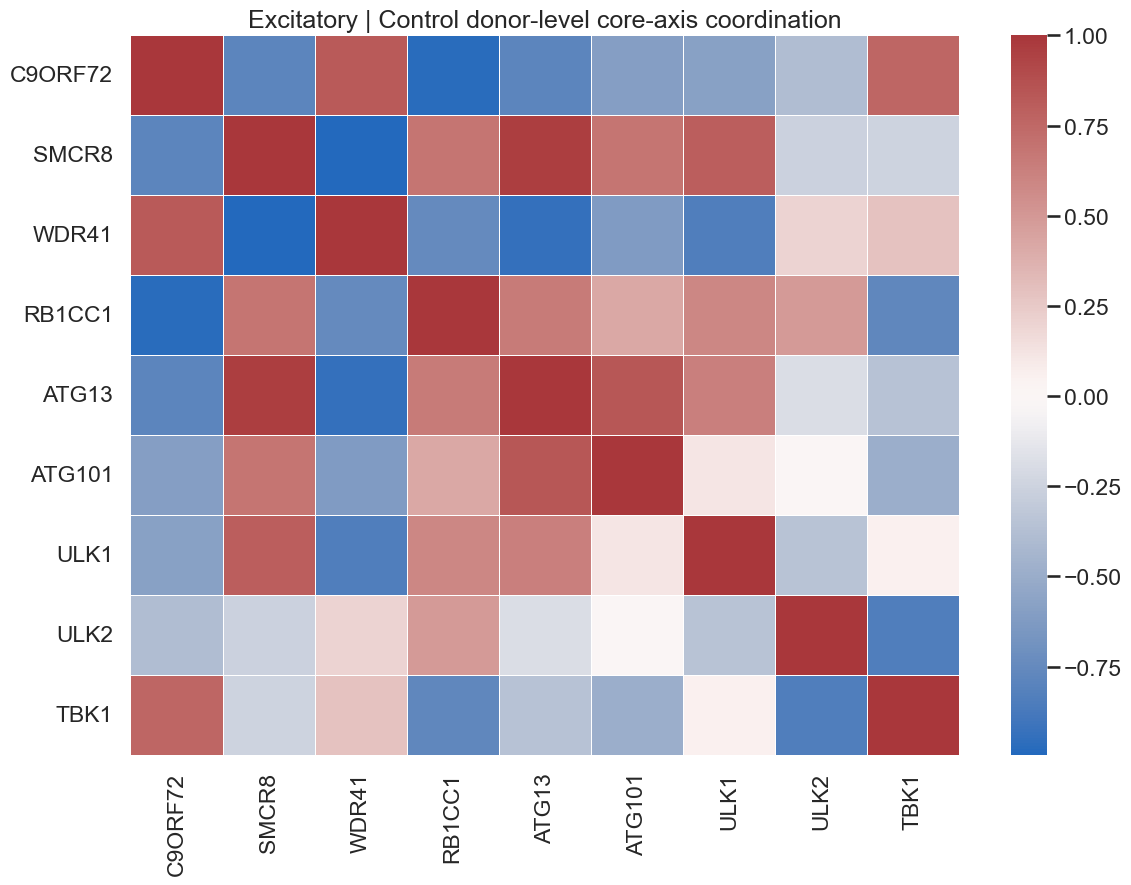

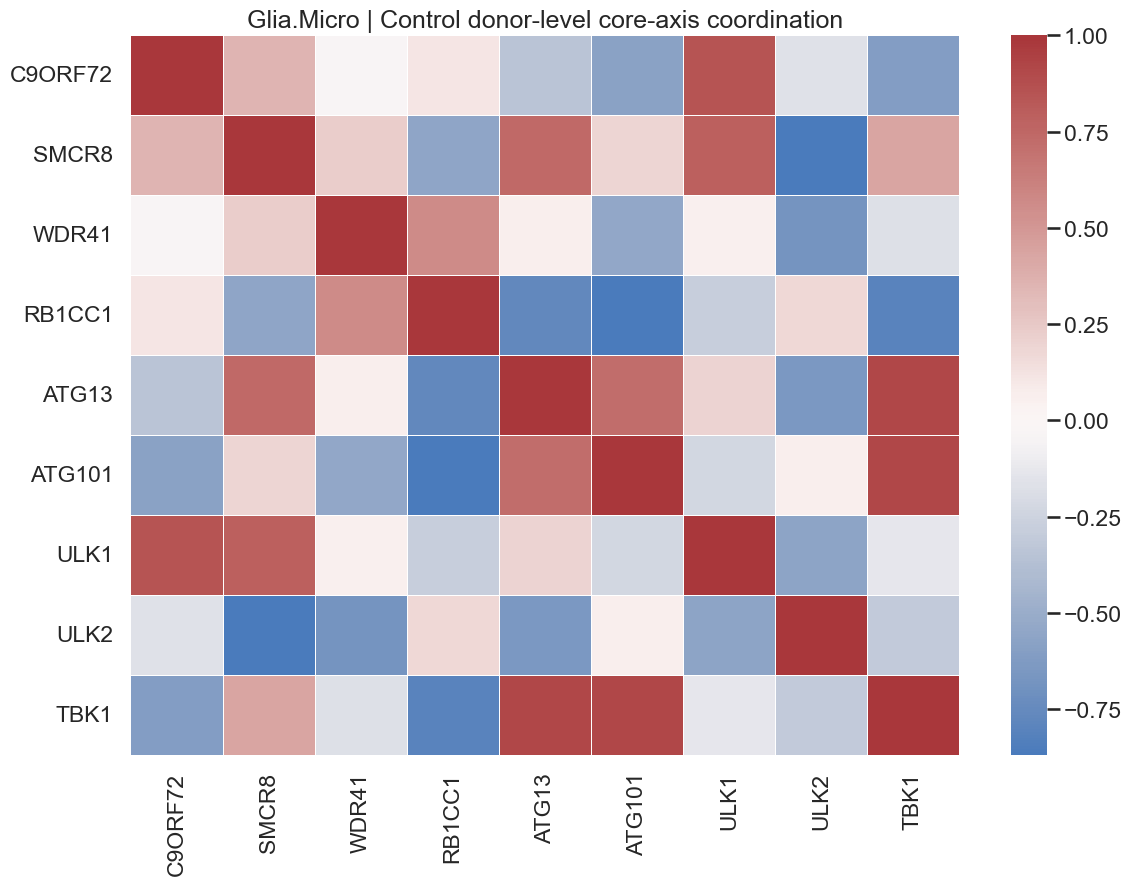

Broad coordination summary:


,level,group_name,n_control_donors,coordination_mean_pairwise_r,coordination_flag
1,broad,Glia,4,-0.017240,tentative_low_n
0,broad,Excitatory,4,-0.077037,tentative_low_n
2,broad,Inhibitory,4,-0.118047,tentative_low_n
3,broad,Vascular,3,NaN,insufficient_donors


Refined subtype coordination summary (top 20 rows):


,level,group_name,n_control_donors,coordination_mean_pairwise_r,coordination_flag
10,subtype,Glia.Astro.GFAP.neg,4,0.049991,tentative_low_n
17,subtype,In.PV.PVALB_MYBPC1,4,-0.036046,tentative_low_n
9,subtype,Ex.L6.TLE4_MEGF11,4,-0.039813,tentative_low_n
16,subtype,In.5HT3aR.DISC1_RELN,4,-0.040716,tentative_low_n
0,subtype,Ex.L2_L3.CUX2_RASGRF2,4,-0.044114,tentative_low_n
1,subtype,Ex.L3_L5.CUX2_RORB,4,-0.047188,tentative_low_n
13,subtype,Glia.Micro,4,-0.049878,tentative_low_n
14,subtype,Glia.OPC,4,-0.050054,tentative_low_n
7,subtype,Ex.L5_L6.THEMIS_TMEM233,4,-0.062671,tentative_low_n
3,subtype,Ex.L4_L6.RORB_LRRK1,4,-0.069023,tentative_low_n


In [ ]:

if not SELECTED_BROAD_CORRELATION_PANELS:
    SELECTED_BROAD_CORRELATION_PANELS = broad_baseline['summary']['group_name'].head(4).tolist()
if not SELECTED_SUBTYPE_CORRELATION_PANELS:
    eligible_subtypes = subtype_baseline['summary']['group_name'].tolist()
    SELECTED_SUBTYPE_CORRELATION_PANELS = eligible_subtypes[:min(6, len(eligible_subtypes))]

broad_coordination, broad_corr_mats = summarise_coordination_from_pseudobulk(
    broad_baseline['logcpm'],
    broad_meta_combined,
    group_col='group_name',
    level_name='broad',
    min_donors=MIN_DONORS_FOR_CORRELATION,
    candidate_groups=SELECTED_BROAD_CORRELATION_PANELS,
)

subtype_coordination, subtype_corr_mats = summarise_coordination_from_pseudobulk(
    subtype_baseline['logcpm'],
    subtype_pb_meta,
    group_col='cell_subtype',
    level_name='subtype',
    min_donors=MIN_DONORS_FOR_CORRELATION,
    candidate_groups=SELECTED_SUBTYPE_CORRELATION_PANELS,
)

print('Broad coordination summary:')
display(broad_coordination)
print('Refined subtype coordination summary (top 20 rows):')
display(subtype_coordination.head(20))



## 5. Disease Perturbation Analysis

At the broad level I reuse the saved donor-level pseudobulk DE results from notebook 12. At the refined subtype level I only run core-panel DE where donor retention is adequate; otherwise I record the retention shortfall and avoid over-interpreting unstable contrasts.



### 5A. Placeholder: Perturbation Thresholds To Review

The thresholds below are used only to count and summarise perturbed genes. They are not a substitute for manual inspection of effect sizes and donor retention.


In [12]:

print('Current perturbation thresholds:')
print({'padj_threshold': PERTURBED_PADJ_THRESHOLD, 'lfc_threshold': PERTURBED_LFC_THRESHOLD})


Current perturbation thresholds:
{'padj_threshold': 0.1, 'lfc_threshold': 0.25}


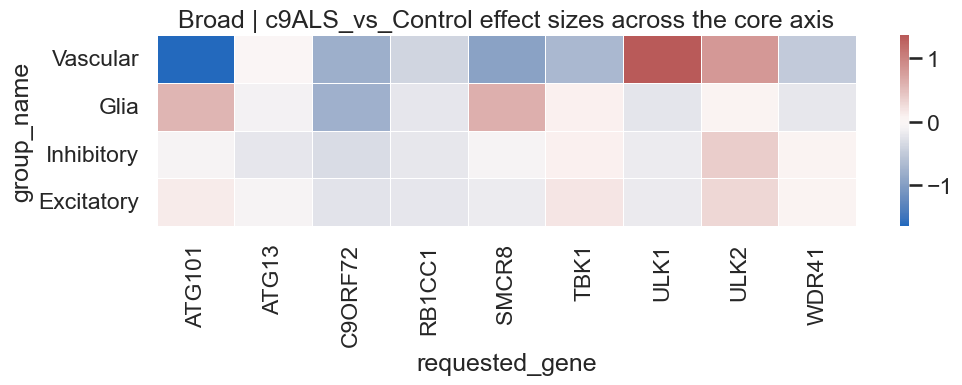

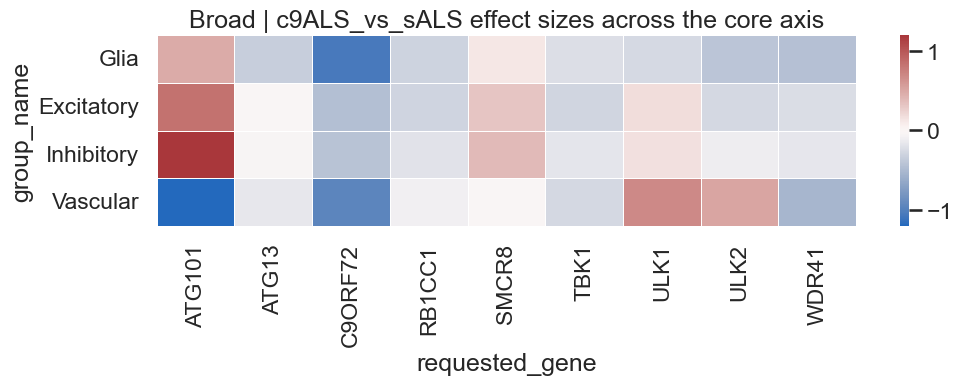

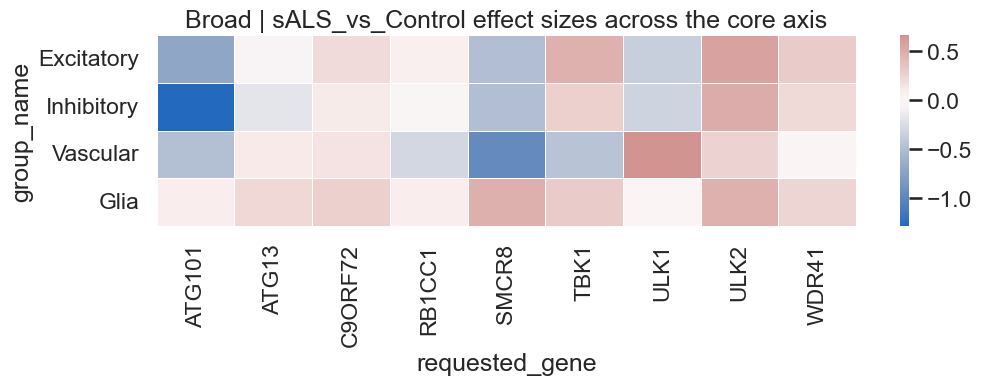

Broad core-axis DE rows:


,group_name,comparison,requested_gene,log2FoldChange,pvalue,padj
0,Excitatory,c9ALS_vs_Control,C9ORF72,-0.258452,0.317639,0.694926
1,Excitatory,c9ALS_vs_Control,SMCR8,-0.177036,0.503008,0.823646
2,Excitatory,c9ALS_vs_Control,WDR41,0.060617,0.780353,0.941019
3,Excitatory,c9ALS_vs_Control,RB1CC1,-0.233902,0.290113,0.668906
4,Excitatory,c9ALS_vs_Control,ATG13,-0.093777,0.630138,0.885339
5,Excitatory,c9ALS_vs_Control,ATG101,0.137945,0.673885,0.905411
6,Excitatory,c9ALS_vs_Control,ULK1,-0.187325,0.400667,0.756139
7,Excitatory,c9ALS_vs_Control,ULK2,0.297408,0.133524,0.473800
8,Excitatory,c9ALS_vs_Control,TBK1,0.179649,0.308785,0.686134
9,Excitatory,c9ALS_vs_sALS,C9ORF72,-0.460071,0.025891,0.104194


Broad perturbation summary:


,group_name,comparison,n_core_genes_tested,n_perturbed_genes,mean_abs_log2fc,mean_abs_log2fc_perturbed,level
0,Excitatory,c9ALS_vs_Control,9,0,0.180679,NaN,broad
1,Excitatory,c9ALS_vs_sALS,9,1,0.324727,0.835166,broad
2,Excitatory,sALS_vs_Control,9,2,0.358632,0.521956,broad
3,Glia,c9ALS_vs_Control,9,0,0.321518,NaN,broad
4,Glia,c9ALS_vs_sALS,9,1,0.405159,1.060978,broad
5,Glia,sALS_vs_Control,9,0,0.241883,NaN,broad
6,Inhibitory,c9ALS_vs_Control,9,0,0.183047,NaN,broad
7,Inhibitory,c9ALS_vs_sALS,9,1,0.320946,0.428612,broad
8,Inhibitory,sALS_vs_Control,9,1,0.376570,0.505736,broad
9,Vascular,c9ALS_vs_Control,9,0,0.797433,NaN,broad


In [13]:

broad_de_core = load_broad_de_core(level_name='broad')
broad_perturbation_summary, broad_perturbation_heatmaps = build_perturbation_summary(
    broad_de_core,
    level_name='broad',
    top_n_plot=None,
)

print('Broad core-axis DE rows:')
display(broad_de_core[['group_name', 'comparison', 'requested_gene', 'log2FoldChange', 'pvalue', 'padj']].head(20))
print('Broad perturbation summary:')
display(broad_perturbation_summary)


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.02 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs Control
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   466.711612       -0.435119  0.215951 -2.014900  0.043915  0.197618
SMCR8      67.305460        0.020049  0.279467  0.071739  0.942809  0.990012
WDR41     409.211609        0.291593  0.203534  1.432645  0.151959  0.341908
RB1CC1   1259.211290       -0.218368  0.127541 -1.712143  0.086870  0.260611
ATG13     290.268763       -0.011874  0.170724 -0.069551  0.944551  0.990012
ATG101     54.238069        0.004736  0.378294  0.012519  0.990012  0.990012
ULK1      334.867035       -0.003416  0.177248 -0.019270  0.984626  0.990012
ULK2      672.913636        0.414948  0.170674  2.431226  0.015048  0.135431
TBK1      323.332480        0.065154  0.196214  0.332055  0.739847  0.990012
Log2 fold change & Wald test p-value: condition c9ALS vs Control
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   466.711612   

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_tren

Log2 fold change & Wald test p-value: condition sALS vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72  338.336827       -0.094841  0.210480 -0.450594  0.652282  0.652282
SMCR8     39.067504       -0.329999  0.243270 -1.356510  0.174937  0.393608
WDR41    259.965513        0.204949  0.200896  1.020177  0.307644  0.553760
RB1CC1   874.596068       -0.064804  0.138225 -0.468826  0.639194  0.652282
ATG13    182.694125       -0.125010  0.198988 -0.628230  0.529854  0.652282
ATG101    28.377905       -0.917939  0.312657 -2.935926  0.003326  0.014965
ULK1     194.774517       -0.448350  0.186708 -2.401347  0.016335  0.049004
ULK2     483.679808        0.625190  0.155847  4.011572  0.000060  0.000543
TBK1     212.930077        0.083935  0.169124  0.496292  0.619689  0.652282
Log2 fold change & Wald test p-value: condition sALS vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72  338.336827       -0.094841 

...

Log2 fold change & Wald test p-value: condition sALS vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   64.376418        0.408802  0.472280  0.865593  0.386713  0.600492
SMCR8     10.036208       -0.669478  0.663736 -1.008651  0.313142  0.600492
WDR41     76.617303        0.371277  0.461074  0.805245  0.420679  0.600492
RB1CC1   222.494056       -0.268605  0.404830 -0.663500  0.507011  0.600492
ATG13     40.785720       -0.156823  0.495433 -0.316536  0.751595  0.751595
ATG101     3.282476       -3.122847  1.382849 -2.258270  0.023929  0.215360
ULK1      25.797064       -0.611562  0.520848 -1.174166  0.240328  0.600492
ULK2     110.307886        0.529798  0.459590  1.152764  0.249007  0.600492
TBK1      35.176778        0.327627  0.526511  0.622260  0.533771  0.600492
Log2 fold change & Wald test p-value: condition sALS vs Control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   64.376418        0.408802 

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.00 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.

Fitting size factors...


Log2 fold change & Wald test p-value: condition c9ALS vs sALS
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   59.538912       -0.069500  0.227431 -0.305589  0.759918  0.933793
SMCR8      7.671324        0.820118  0.698597  1.173951  0.240415  0.933793
WDR41     58.609431       -0.058063  0.227766 -0.254922  0.798783  0.933793
RB1CC1   160.308318       -0.012790  0.153962 -0.083074  0.933793  0.933793
ATG13     31.982838        0.076125  0.310997  0.244778  0.806628  0.933793
ATG101     2.871863        1.433403  1.134701  1.263243  0.206502  0.933793
ULK1      24.025535       -0.240458  0.343266 -0.700501  0.483614  0.933793
ULK2      99.935171        0.028157  0.191307  0.147184  0.882987  0.933793
TBK1      36.639968        0.032310  0.279068  0.115778  0.907829  0.933793
Log2 fold change & Wald test p-value: condition c9ALS vs sALS
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   59.538912       -0.069500  0.2

Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.00 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs sALS
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   7.910335        0.120465  0.510541  0.235955  0.813468  0.934628
SMCR8     0.943627        1.367519  1.406151  0.972526  0.330789  0.820386
WDR41    18.708842       -0.401666  0.443044 -0.906605  0.364616  0.820386
RB1CC1   22.453846        0.544185  0.363361  1.497641  0.134227  0.604020
ATG13     7.560158       -0.097136  0.521957 -0.186100  0.852366  0.934628
ATG101    1.385078       -0.107965  1.316268 -0.082024  0.934628  0.934628
ULK1      5.730273        1.087071  0.642753  1.691273  0.090785  0.604020
ULK2      7.156084       -0.190172  0.662674 -0.286976  0.774131  0.934628
TBK1      6.932690       -0.159247  0.539981 -0.294912  0.768061  0.934628
Log2 fold change & Wald test p-value: condition c9ALS vs sALS
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
C9ORF72   7.910335        0.120465  0.510541  0.235

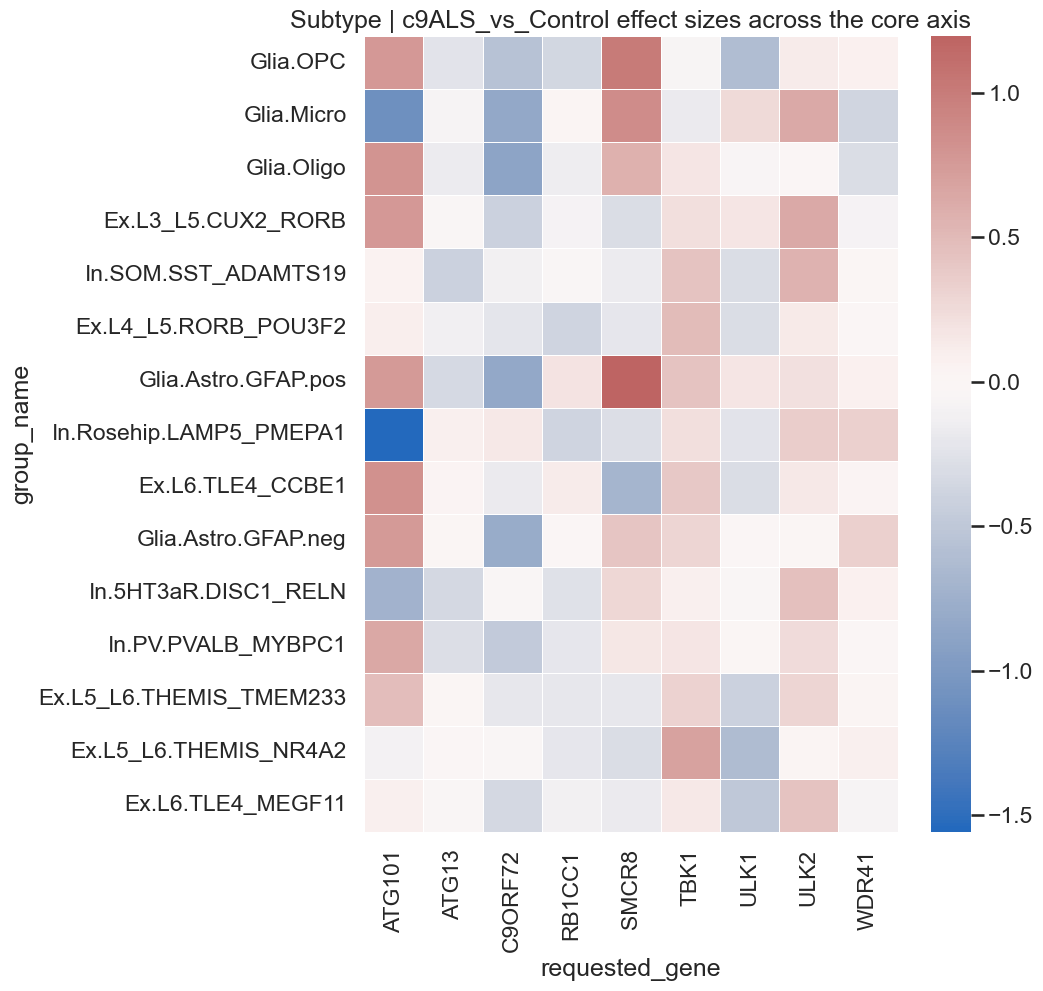

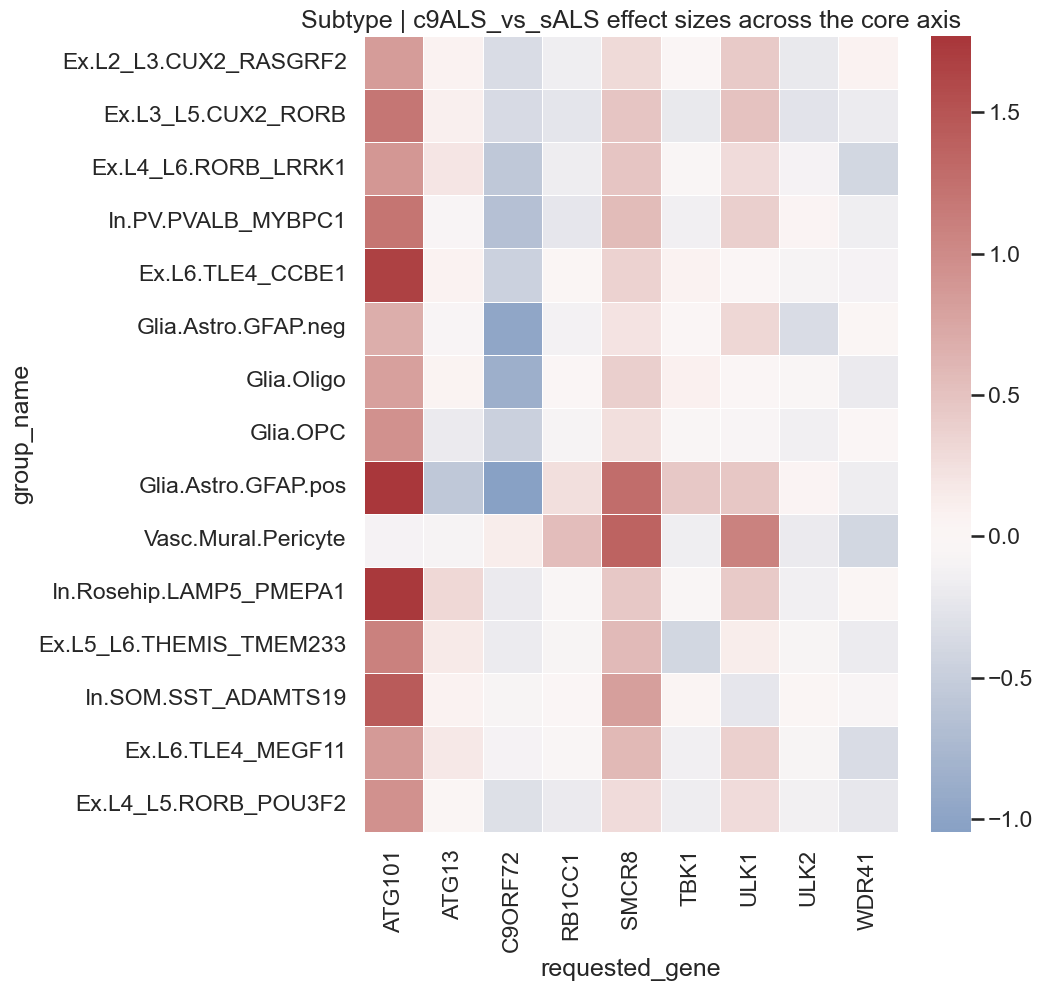

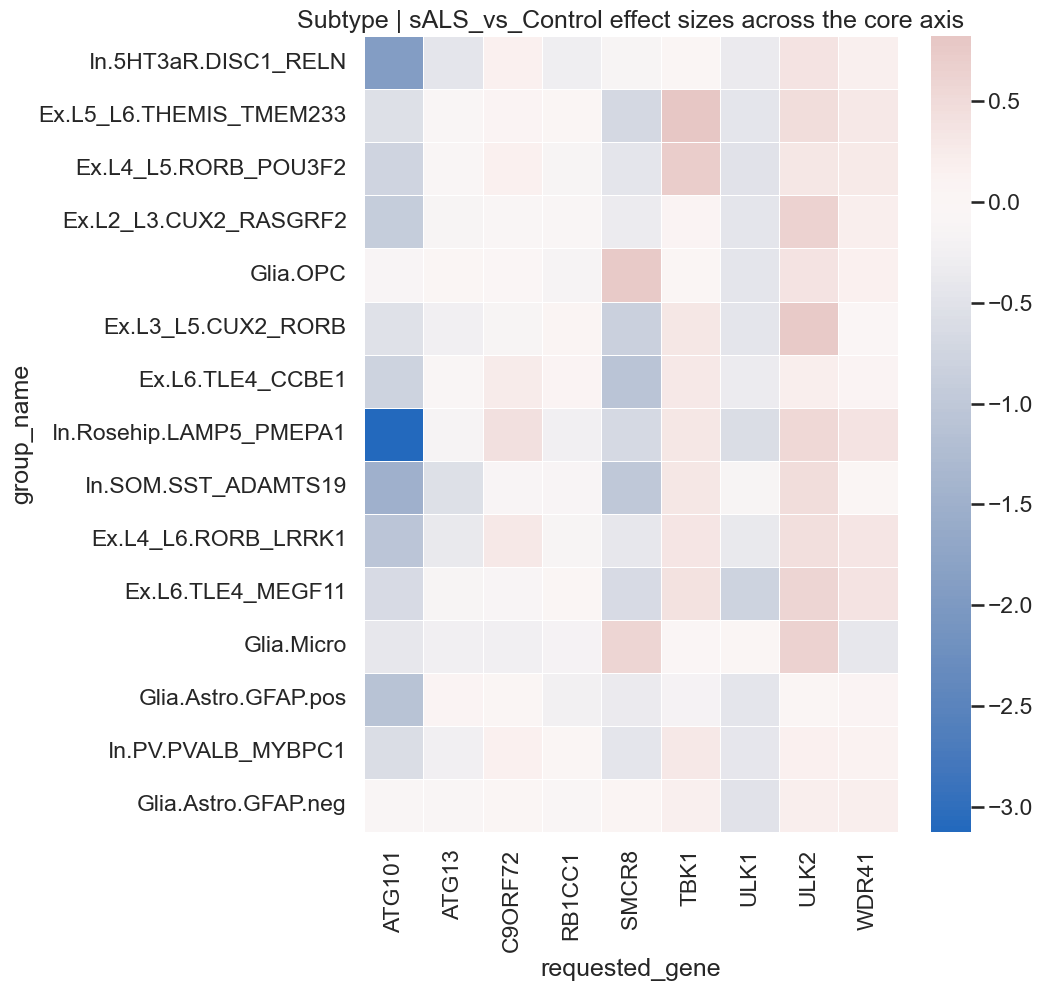

Subtype DE failures / skipped comparisons:


,group_name,comparison,status,n_test_donors,n_ref_donors
0,Ex.L5.PCP4_NXPH2,c9ALS_vs_sALS,insufficient_donors,4,2
1,Ex.L5.PCP4_NXPH2,sALS_vs_Control,insufficient_donors,2,3
2,Ex.L5.VAT1L_THSD4,c9ALS_vs_Control,insufficient_donors,2,1
3,Ex.L5.VAT1L_THSD4,c9ALS_vs_sALS,insufficient_donors,2,1
4,Ex.L5.VAT1L_THSD4,sALS_vs_Control,insufficient_donors,1,1
5,Ex.L5_L6.THEMIS_NR4A2,c9ALS_vs_sALS,insufficient_donors,4,2
6,Ex.L5_L6.THEMIS_NR4A2,sALS_vs_Control,insufficient_donors,2,3
7,Glia.Astro_Micro_mixed,c9ALS_vs_Control,insufficient_donors,2,2
8,Glia.Astro_Micro_mixed,c9ALS_vs_sALS,insufficient_donors,2,0
9,Glia.Astro_Micro_mixed,sALS_vs_Control,insufficient_donors,0,2


Subtype perturbation summary:


,group_name,comparison,n_core_genes_tested,n_perturbed_genes,mean_abs_log2fc,mean_abs_log2fc_perturbed,level
0,Ex.L2_L3.CUX2_RASGRF2,c9ALS_vs_Control,9,0,0.162806,NaN,subtype
1,Ex.L2_L3.CUX2_RASGRF2,c9ALS_vs_sALS,9,3,0.277140,0.542044,subtype
2,Ex.L2_L3.CUX2_RASGRF2,sALS_vs_Control,9,3,0.321669,0.663826,subtype
3,Ex.L3_L5.CUX2_RORB,c9ALS_vs_Control,9,1,0.300216,0.626848,subtype
4,Ex.L3_L5.CUX2_RORB,c9ALS_vs_sALS,9,2,0.395561,0.853242,subtype
5,Ex.L3_L5.CUX2_RORB,sALS_vs_Control,9,1,0.381154,0.767574,subtype
6,Ex.L4_L5.RORB_POU3F2,c9ALS_vs_Control,9,1,0.221520,0.384620,subtype
7,Ex.L4_L5.RORB_POU3F2,c9ALS_vs_sALS,9,0,0.284538,NaN,subtype
8,Ex.L4_L5.RORB_POU3F2,sALS_vs_Control,9,3,0.379472,0.518178,subtype
9,Ex.L4_L6.RORB_LRRK1,c9ALS_vs_Control,9,0,0.186001,NaN,subtype


In [14]:

subtype_de_core, subtype_de_failures = run_subtype_core_de(
    subtype_pb_counts,
    subtype_pb_meta,
    group_col='cell_subtype',
    min_donors_per_condition=MIN_DONORS_PER_CONDITION_FOR_SUBTYPE_DE,
)

subtype_perturbation_summary, subtype_perturbation_heatmaps = build_perturbation_summary(
    subtype_de_core,
    level_name='subtype',
    top_n_plot=TOP_N_SUBTYPES_TO_PLOT_FOR_PERTURBATION,
)

print('Subtype DE failures / skipped comparisons:')
display(subtype_de_failures.head(20))
print('Subtype perturbation summary:')
display(subtype_perturbation_summary.head(20))



## 6. Integrated Prioritisation Of Cell Types

I combine four transparent ingredients for prioritisation:

1. baseline pathway representation in controls
2. coordination of the core axis in controls
3. disease-associated perturbation in C9-ALS
4. donor retention as a simple robustness term

The default weighting is deliberately simple and editable rather than pretending to be fully objective.


In [15]:

broad_prioritisation = build_prioritisation_table(
    level_name='broad',
    baseline_summary=broad_baseline['summary'],
    coordination_summary=broad_coordination,
    perturbation_summary=broad_perturbation_summary,
    retention_summary=broad_retention_summary,
)

subtype_prioritisation = build_prioritisation_table(
    level_name='subtype',
    baseline_summary=subtype_baseline['summary'],
    coordination_summary=subtype_coordination,
    perturbation_summary=subtype_perturbation_summary,
    retention_summary=subtype_retention_summary,
)

print('Broad prioritisation:')
display(broad_prioritisation)
print('Top refined subtypes by integrated prioritisation:')
display(subtype_prioritisation.head(20))


Broad prioritisation:


,group_name,baseline_pathway_score,n_control_donors,coordination_mean_pairwise_r,coordination_flag,perturbation_metric,n_perturbed_core_genes,min_retained_donors,level,baseline_scaled,coordination_scaled,perturbation_scaled,robustness_scaled,prioritisation_score,prioritisation_rank
0,Excitatory,0.158687,4,-0.077037,tentative_low_n,0.252703,1,4,broad,1.000000,0.40682,0.001790,1.0,1.908611,1
1,Glia,-0.284372,4,-0.017240,tentative_low_n,0.363339,1,4,broad,0.000000,1.00000,0.282262,1.0,1.782262,2
2,Vascular,0.032124,3,NaN,insufficient_donors,0.646459,0,3,broad,0.714344,0.00000,1.000000,0.0,1.714344,3
3,Inhibitory,0.093561,4,-0.118047,tentative_low_n,0.251997,1,4,broad,0.853009,0.00000,0.000000,1.0,1.353009,4


Top refined subtypes by integrated prioritisation:


,group_name,baseline_pathway_score,n_control_donors,coordination_mean_pairwise_r,coordination_flag,perturbation_metric,n_perturbed_core_genes,min_retained_donors,level,baseline_scaled,coordination_scaled,perturbation_scaled,robustness_scaled,prioritisation_score,prioritisation_rank
0,Glia.Astro.GFAP.neg,-0.055990,4,0.049991,tentative_low_n,0.299677,1.0,4,subtype,0.606052,1.000000,0.524290,1.000000,2.630341,1
1,Glia.Micro,0.139800,4,-0.049878,tentative_low_n,0.376678,2.0,4,subtype,0.997747,0.396188,0.659004,1.000000,2.552940,2
2,In.PV.PVALB_MYBPC1,0.061888,4,-0.036046,tentative_low_n,0.315089,1.0,4,subtype,0.841878,0.479815,0.551253,1.000000,2.372947,3
3,In.5HT3aR.DISC1_RELN,0.104933,4,-0.040716,tentative_low_n,0.254609,0.0,4,subtype,0.927993,0.451583,0.445442,1.000000,2.325017,4
4,Ex.L5_L6.THEMIS_TMEM233,0.140926,4,-0.062671,tentative_low_n,0.277926,0.0,4,subtype,1.000000,0.318841,0.486236,1.000000,2.305077,5
5,Ex.L3_L5.CUX2_RORB,0.095627,4,-0.047188,tentative_low_n,0.347889,3.0,3,subtype,0.909375,0.412454,0.608637,0.666667,2.263799,6
6,Ex.L2_L3.CUX2_RASGRF2,0.081984,4,-0.044114,tentative_low_n,0.219973,3.0,4,subtype,0.882081,0.431035,0.384846,1.000000,2.197963,7
7,Glia.OPC,-0.003223,4,-0.050054,tentative_low_n,0.334621,5.0,4,subtype,0.711618,0.395126,0.585425,1.000000,2.192169,8
8,Ex.L6.TLE4_CCBE1,0.072887,4,-0.078437,tentative_low_n,0.311022,1.0,4,subtype,0.863883,0.223521,0.544138,1.000000,2.131541,9
9,Ex.L6.TLE4_MEGF11,0.059404,4,-0.039813,tentative_low_n,0.257830,0.0,3,subtype,0.836909,0.457044,0.451077,0.666667,2.078362,10



## 7. Publication-Ready Output Inventory

I save the key tables and figures under a notebook-specific results folder so the prioritisation logic is easy to audit later.


In [16]:

output_inventory = pd.DataFrame({
    'tables': sorted(str(path.relative_to(PROJECT_ROOT)) for path in TABLE_DIR.glob('*.csv'))[:200],
})

print(f'Results directory: {RESULTS_14_DIR}')
print('Saved tables:')
display(pd.Series(sorted(str(path.relative_to(PROJECT_ROOT)) for path in TABLE_DIR.glob('*.csv')), name='table_path').to_frame())
print('Saved figures:')
display(pd.Series(sorted(str(path.relative_to(PROJECT_ROOT)) for path in FIG_DIR.glob('*.png')), name='figure_path').to_frame())


Results directory: /Users/wangj/Documents/Computational_Biology/Projects/C9_Multiomics/results/14_celltype_prioritisation_C9_SMCR8_ULK_axis
Saved tables:


,table_path
0,results/14_celltype_prioritisation_C9_SMCR8_UL...
1,results/14_celltype_prioritisation_C9_SMCR8_UL...
2,results/14_celltype_prioritisation_C9_SMCR8_UL...
3,results/14_celltype_prioritisation_C9_SMCR8_UL...
4,results/14_celltype_prioritisation_C9_SMCR8_UL...
5,results/14_celltype_prioritisation_C9_SMCR8_UL...
6,results/14_celltype_prioritisation_C9_SMCR8_UL...
7,results/14_celltype_prioritisation_C9_SMCR8_UL...
8,results/14_celltype_prioritisation_C9_SMCR8_UL...
9,results/14_celltype_prioritisation_C9_SMCR8_UL...


Saved figures:


,figure_path
0,results/14_celltype_prioritisation_C9_SMCR8_UL...
1,results/14_celltype_prioritisation_C9_SMCR8_UL...
2,results/14_celltype_prioritisation_C9_SMCR8_UL...
3,results/14_celltype_prioritisation_C9_SMCR8_UL...
4,results/14_celltype_prioritisation_C9_SMCR8_UL...
5,results/14_celltype_prioritisation_C9_SMCR8_UL...
6,results/14_celltype_prioritisation_C9_SMCR8_UL...
7,results/14_celltype_prioritisation_C9_SMCR8_UL...
8,results/14_celltype_prioritisation_C9_SMCR8_UL...
9,results/14_celltype_prioritisation_C9_SMCR8_UL...



## 8. Final Interpretation Draft

This section is meant to make the current state of the evidence explicit before any final biological claims are fixed. I first generate a data-driven draft summary, then leave a short markdown template for manual revision.


In [17]:

def summarise_top_hits(prioritisation_df, n=3):
    if prioritisation_df.empty:
        return []
    return prioritisation_df['group_name'].head(n).tolist()

robust_broad = broad_prioritisation.loc[broad_prioritisation['min_retained_donors'] >= MIN_DONORS_PER_CONDITION_FOR_SUBTYPE_DE, 'group_name'].tolist()
robust_subtypes = subtype_prioritisation.loc[subtype_prioritisation['min_retained_donors'] >= MIN_DONORS_PER_CONDITION_FOR_SUBTYPE_DE, 'group_name'].tolist()

draft_summary = f"""
### Draft summary generated from the current notebook state

- **Most compelling broad classes right now:** {', '.join(summarise_top_hits(broad_prioritisation, n=3)) if not broad_prioritisation.empty else 'not yet available'}.
- **Most promising refined subtypes right now:** {', '.join(summarise_top_hits(subtype_prioritisation, n=5)) if not subtype_prioritisation.empty else 'not yet available'}.
- **Broad classes with acceptable donor robustness under the current thresholds:** {', '.join(robust_broad) if robust_broad else 'none'}.
- **Refined subtypes with acceptable donor robustness under the current thresholds:** {', '.join(robust_subtypes[:10]) if robust_subtypes else 'none'}.
- **Main caveat:** refined subtype disease contrasts are only interpretable where donor retention and DE convergence were adequate; the failure and retention tables should be checked before making subtype-level claims.
"""

display(Markdown(draft_summary))



### Draft summary generated from the current notebook state

- **Most compelling broad classes right now:** Excitatory, Glia, Vascular.
- **Most promising refined subtypes right now:** Glia.Astro.GFAP.neg, Glia.Micro, In.PV.PVALB_MYBPC1, In.5HT3aR.DISC1_RELN, Ex.L5_L6.THEMIS_TMEM233.
- **Broad classes with acceptable donor robustness under the current thresholds:** Excitatory, Glia, Vascular, Inhibitory.
- **Refined subtypes with acceptable donor robustness under the current thresholds:** Glia.Astro.GFAP.neg, Glia.Micro, In.PV.PVALB_MYBPC1, In.5HT3aR.DISC1_RELN, Ex.L5_L6.THEMIS_TMEM233, Ex.L3_L5.CUX2_RORB, Ex.L2_L3.CUX2_RASGRF2, Glia.OPC, Ex.L6.TLE4_CCBE1, Ex.L6.TLE4_MEGF11.
- **Main caveat:** refined subtype disease contrasts are only interpretable where donor retention and DE convergence were adequate; the failure and retention tables should be checked before making subtype-level claims.



### Manual Interpretation Placeholder

Please edit this section after reviewing the saved tables and figures.

- **Broad-level priorities:**
  - [Edit after inspection]
- **Refined subtype priorities:**
  - [Edit after inspection]
- **Results that appear robust:**
  - [Edit after inspection]
- **Results that remain tentative because of donor retention, low coordination sample size, or unstable subtype DE:**
  - [Edit after inspection]
- **Manual decisions still pending:**
  - whether the default pathway score weighting should remain equal-weight
  - whether the perturbation thresholds are appropriate for the final figure set
  - whether any subtype-level claims should be restricted further on robustness grounds
